# Phase 3 — Continuous Decoding · DANDI_000688

Predicts hand velocity (vx, vy) from binned spike counts using Ridge, Wiener 
Filter, Wiener-Ridge, and Kalman Filter on DANDI_000688.
Cross-validation uses a trial-boundary-respecting K-Fold (80-10-10 split).

| Cell | Content |
|------|---------|
| 1  | Imports |
| 2  | Session load (DANDI_000688, local zarr) |
| 3  | Feature extraction: binned spikes + velocity → per-trial chunks via `get_trial_data` |
| 4  | Velocity visualization: vx and vy over time (raw data, before decoding) |
| 5  | Trial-boundary 80-10-10 train/test split |
| 6  | PCA exploration + fit (N_PCA selected at 90% variance) |
| 7  | K-Fold CV over trainval: HP selection for all decoders |
| 8  | Final evaluation: best HPs on held-out test set (reported to JP) |
| 9  | Kalman diagnostics: transition matrix A, Q/W ratio analysis |
| 10 | Summary table |
| 11 | Predicted vs actual velocity plots |

**Session:** DANDI_000688 · subject C · session 20131203 · center-out task  
294 electrodes · 175 trials · bin size 50ms · vx ≠ vy confirmed

In [27]:
from pathlib import Path
from sklearn.decomposition import PCA
import sys
_repo_root = Path.cwd() if (Path.cwd() / "decoding").is_dir() else Path.cwd().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import os
import configparser
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bci_decoding_dataset import DatasetLoader

from decoding import (
    compute_bin_phases,
    compute_binned_counts,
    compute_binned_trial_ids,
    DimReducer,
    KalmanFilterDecoder,
    RidgeDecoder,
    WienerFilterDecoder,
    WienerRidgeDecoder,
)

sns.set_theme(style="whitegrid", font_scale=1.1)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# ── Pipeline parameters (only values that may need tuning) ──────────────────
BIN_SIZE_MS = 50    # spike binning window (ms)
N_LAGS      = 10     # Wiener filter: past bins appended as features
TRAIN_FRAC  = 0.80  # temporal train/test split
PLOT_BINS   = 200   # bins shown in trace plots

# ── AWS credentials from ~/.aws/credentials ─────────────────────────────────
#credentials_path = os.path.expanduser("~/.aws/credentials")
#config = configparser.ConfigParser()
#config.read(credentials_path)
#profile = os.environ.get("AWS_PROFILE", "cv-pc")

# ── Local dataset path ───────────────────────────────────────────────────────
LOCAL_DATASET_PATH = "/home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_v9.zarr"

print("✓ All imports successful")
print(f"bin_size_ms  : {BIN_SIZE_MS}  |  n_lags: {N_LAGS}  |  train: {int(TRAIN_FRAC*100)}%")
print(f"Dataset path : {LOCAL_DATASET_PATH}")

✓ All imports successful
bin_size_ms  : 50  |  n_lags: 10  |  train: 80%
Dataset path : /home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_v9.zarr


## S3 Connection + Session Load

DANDI_000688 has ~54 electrodes, ~111 sessions, ~180 trials/session.
Velocity has been confirmed correct for this dataset (vx ≠ vy).

In [28]:
#loader = DatasetLoader(
    #aws_store=True,
    #s3_bucket="solzbacher-lab-motor-decoding-ds",
    #s3_key="datasets/Combined_Motor_Datasets",
    #aws_access_key_id=config[profile]["aws_access_key_id"],
    #aws_secret_access_key=config[profile]["aws_secret_access_key"],)

# AHORA
loader = DatasetLoader(
    aws_store=False,
    combined_dataset_path="/home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_V9.zarr",
)

sessions  = loader.filter_sessions("dataset_id", "DANDI_000688")
session_id = sessions[8] #1 es 688 subject T 

#8 es subject T 64 electrodos, 20130905
#22 es la 20131203 subject C
ds = loader.get_processed_data_from_session(session_id)
from decoding.data_loading import merge_session_attrs
merge_session_attrs(loader, session_id, ds)

print(f"Session:        {session_id}")
print(f"Subject:        {ds.attrs.get('subject_id', 'unknown')}")
print(f"Task:           {ds.attrs.get('task_type', 'unknown')}")
print(f"Sampling rate:  {ds.attrs.get('sampling_rate', 'unknown')} Hz")
print(f"Spikes shape:   {ds['spikes'].shape}  (n_electrodes × n_time)")
print(f"Velocity shape: {ds['velocity'].shape}")
print("✓ Connected to local dataset and session loaded")
print(ds.attrs)  

Reading data from session: 20130905
Session:        20130905
Subject:        T
Task:           center_out
Sampling rate:  1000.0 Hz
Spikes shape:   (64, 908452)  (n_electrodes × n_time)
Velocity shape: (908452, 2)
✓ Connected to local dataset and session loaded
{'acceleration_max': [194.67339503043775, 226.49851125435478], 'acceleration_min': [-182.15960105029492, -223.6989634018389], 'dataset_id': 'DANDI_000688', 'n_trials': 212, 'normalization_method': 'global-z-score-p99', 'normalization_range': [-1.0, 1.0], 'position_max': [8.937249688941721, 8.09112365937505], 'position_min': [-8.499455731113205, -8.604610908206524], 'sampling_rate': 1000.0, 'task_type': 'center_out', 'velocity_global_mean': [-0.00025834030378904424, 0.00040956493699241303], 'velocity_global_scale': [3.4987658949644596, 3.865083030202896], 'velocity_global_std': [7.3848952223456275, 6.848592494879897], '.specloc': 'specifications', 'decoding_type': 'motor', 'namespace': 'core', 'neurodata_type': 'NWBFile', 'nwb_ve

In [29]:
sessions = loader.filter_sessions("dataset_id", "DANDI_000688")
for i, s in enumerate(sessions):
    print(f"[{i}] {s}")

[0] 20130819
[1] 20130820
[2] 20130821
[3] 20130822
[4] 20130823
[5] 20130830
[6] 20130903
[7] 20130904
[8] 20130905
[9] 20130906
[10] 20130909
[11] 20130910
[12] 20131003
[13] 20131009
[14] 20131010
[15] 20131011
[16] 20131022
[17] 20131023
[18] 20131028
[19] 20131029
[20] 20131031
[21] 20131101
[22] 20131203
[23] 20131204
[24] 20131209
[25] 20131210
[26] 20131212
[27] 20131213
[28] 20131217
[29] 20131218
[30] 20131219
[31] 20131220
[32] 20140114
[33] 20140115
[34] 20140116
[35] 20140203
[36] 20140214
[37] 20140217
[38] 20140218
[39] 20140221
[40] 20140224
[41] 20140303
[42] 20140304
[43] 20140306
[44] 20140307
[45] 20140626
[46] 20140627
[47] 20140929
[48] 20141203
[49] 20150309
[50] 20150311
[51] 20150312
[52] 20150313
[53] 20150316
[54] 20150317
[55] 20150318
[56] 20150319
[57] 20150320
[58] 20150511
[59] 20150512
[60] 20150610
[61] 20150611
[62] 20150612
[63] 20150615
[64] 20150616
[65] 20150617
[66] 20150623
[67] 20150625
[68] 20150626
[69] 20150629
[70] 20150630
[71] 20150701
[7

## Feature Extraction

**Block 1 — Spike binning**
`compute_binned_counts` sums spikes in non-overlapping 50 ms windows →
`X_all` of shape `(n_bins, n_electrodes)`.

**Block 2 — Trial ID binning**
`compute_binned_trial_ids` downsamples the 1 kHz `trial_id` signal to bin
resolution by taking the mode over each 50 ms window, producing
`trial_id_binned` aligned sample-for-sample with `X_all`.

**Block 3 — Velocity binning**
`velocity` (1 kHz) is mean-pooled over the same 50 ms windows →
`y_all` of shape `(n_bins, 2)`. Mean pooling matches the spike-count
integration window and preserves the sign of each velocity component.

**Block 4 — Trial chunking**
`get_trial_data` groups every bin into a per-trial dict keyed by `trial_id`.
Only bins with **positive** trial IDs are kept — those belonging to an active
reach trial. Bins with ID = 0 (transitions / padding) and negative IDs
(inter-trial intervals) are discarded.

Importantly, **all phases within each trial are retained** — pre-reach,
reach, and post-reach alike. Filtering to the reach phase only
(`trial_phase == 2`) would bias the decoder toward high-velocity dynamics
and suppress the baseline neural activity that anchors velocity predictions
near zero.

**Block 5 — Verification**
The prints confirm total trial count, per-trial bin length (min / max / mean),
and velocity range. The `assert not np.allclose(vx, vy)` guards against the
known vx == vy duplication bug present in other datasets.

In [30]:
X_all      = compute_binned_counts(ds, bin_size_ms=BIN_SIZE_MS)   # (n_bins, n_el)
n_bins     = X_all.shape[0]
trial_id_binned = compute_binned_trial_ids(ds, bin_size_ms=BIN_SIZE_MS)  # (n_bins,)

velocity  = ds["velocity"].values          # (n_time, 2), float32
n_trimmed = n_bins * BIN_SIZE_MS
y_all = velocity[:n_trimmed].reshape(n_bins, BIN_SIZE_MS, 2).mean(axis=1)  # (n_bins, 2)

from decoding.discrete_utils import get_trial_data
trials = get_trial_data(X_all, y_all, trial_id_binned)

print(f"Total trials: {len(trials)}")
print(f"Trial lengths (bins): min={min(len(t['X']) for t in trials)}, "
      f"max={max(len(t['X']) for t in trials)}, "
      f"mean={np.mean([len(t['X']) for t in trials]):.1f}")

vx_all = np.concatenate([t['y'][:, 0] for t in trials])
vy_all = np.concatenate([t['y'][:, 1] for t in trials])
print(f"vx range: [{vx_all.min():.3f}, {vx_all.max():.3f}]")
print(f"vy range: [{vy_all.min():.3f}, {vy_all.max():.3f}]")
assert not np.allclose(vx_all, vy_all), "vx == vy bug detected — wrong dataset"
print("✓ vx ≠ vy confirmed")

Total trials: 175
Trial lengths (bins): min=53, max=246, mean=87.0
vx range: [-0.858, 0.823]
vy range: [-1.055, 0.979]
✓ vx ≠ vy confirmed


## Velocity Signal — Raw Data

vx and vy over time for the full session (all active reach bins concatenated).
This shows the structure of the decoding target before any model is applied.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Concatenate all trial velocity data
vx_all = np.concatenate([t['y'][:, 0] for t in trials])
vy_all = np.concatenate([t['y'][:, 1] for t in trials])
time_s = np.arange(len(vx_all)) * BIN_SIZE_MS / 1000  # seconds

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=("vx (horizontal velocity)", 
                                    "vy (vertical velocity)"),
                    vertical_spacing=0.08)

fig.add_trace(go.Scatter(x=time_s, y=vx_all, mode='lines',
                         line=dict(color='#2d6a9f', width=0.8),
                         name='vx'), row=1, col=1)

fig.add_trace(go.Scatter(x=time_s, y=vy_all, mode='lines',
                         line=dict(color='#e05c2a', width=0.8),
                         name='vy'), row=2, col=1)

fig.update_layout(
    title=f"Raw Velocity Signal — Session {session_id} (DANDI_000688)<br>"
          f"<sup>{len(trials)} trials · {len(vx_all)} bins · {BIN_SIZE_MS}ms bins</sup>",
    height=500,
    showlegend=True,
    template='plotly_dark'
)
fig.update_xaxes(title_text="Time (s)", row=2, col=1)
fig.update_yaxes(title_text="Velocity (norm.)", row=1, col=1)
fig.update_yaxes(title_text="Velocity (norm.)", row=2, col=1)
fig.show()

## Train/Test Split (80-10-10)

Trial-boundary 90/10 split: first 90% of trials → trainval, last 10% → test.
`test_trials` is never touched until the final evaluation cell.

Inside the K-Fold loop, `trainval_trials` is further split into ~80% train /
~10% val per fold — giving the 80-10-10 structure overall.

**Note (Wiener boundary):** When a train fold is assembled by concatenating trial
chunks, `_build_lagged_features` still crosses within-concatenation trial
boundaries for the first `n_lags` bins of each trial. Acceptable for HP
selection; will be resolved if a fully clean per-trial evaluation is warranted.

In [31]:
# cuantos trials van a test (last 10%) y cuantos a trainval (first 90%)
n_total    = len(trials) #cuantos trials en esta sesión
n_test     = round(n_total * 0.10)   # last 10% → test, never touched
n_trainval = n_total - n_test        # remaining 90% → K-Fold

# split trials into trainval and test sets (temporal split: last 10% of trials for test)
test_trials     = trials[n_trainval:]
trainval_trials = trials[:n_trainval]

#concatena chunks de cada trial en arrays planos para poder usarlos en los decoders (n_bins_total, n_electrodes) y (n_bins_total, 2)
X_train = np.concatenate([t['X'] for t in trainval_trials])
y_train = np.concatenate([t['y'] for t in trainval_trials])
X_test  = np.concatenate([t['X'] for t in test_trials])
y_test  = np.concatenate([t['y'] for t in test_trials])

print(f"TrainVal: {len(trainval_trials)} trials, {X_train.shape[0]} bins "
      f"({X_train.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")
print(f"Test:     {len(test_trials)} trials, {X_test.shape[0]} bins "
      f"({X_test.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")

TrainVal: 157 trials, 13570 bins (678.5 s)
Test:     18 trials, 1654 bins (82.7 s)


## PCA


In [32]:
n_components = min(X_train.shape[0], X_train.shape[1]) - 1
pca_raw = PCA(n_components=n_components)
pca_raw.fit(X_train)

cumvar = np.cumsum(pca_raw.explained_variance_ratio_)
for threshold in [0.50, 0.70, 0.80, 0.90]:
    n = np.searchsorted(cumvar, threshold) + 1
    print(f"{threshold*100:.0f}% varianza → {n} componentes")

print(f"\nTotal componentes disponibles: {n_components}")
print(f"Varianza total explicada: {cumvar[-1]*100:.1f}%")

50% varianza → 12 componentes
70% varianza → 21 componentes
80% varianza → 27 componentes
90% varianza → 38 componentes

Total componentes disponibles: 63
Varianza total explicada: 100.0%


 `fit_transform(X_train)` hace dos cosas:

fit: aprende las direcciones principales (eigenvectors) a partir de X_train
transform: proyecta X_train sobre esas direcciones

`transform(X_test)` hace solo una cosa:

Toma las direcciones que ya aprendió del train y proyecta X_test sobre ellas
No aprende nada nuevo de X_test

In [33]:
N_PCA = 38 # + 80% varianza explicada !!!

pca_raw = PCA(n_components=N_PCA)
X_train_pca = pca_raw.fit_transform(X_train)   # fit solo en train
X_test_pca  = pca_raw.transform(X_test)        # transform en test

print(f"X_train: {X_train.shape} → {X_train_pca.shape}")
print(f"X_test:  {X_test.shape}  → {X_test_pca.shape}")
print(f"Varianza explicada: {pca_raw.explained_variance_ratio_.sum()*100:.1f}%")

X_train: (13570, 64) → (13570, 38)
X_test:  (1654, 64)  → (1654, 38)
Varianza explicada: 90.6%


## K-Fold Cross-Validation (Hyperparameter Selection)

Trial-based K-Fold CV over `trainval_trials` only — `test_trials` are never touched here.

Each fold holds out a contiguous block of ~10% of trainval trials as validation
(≈10% of total), giving ~1000 val bins per fold — enough for stable R² estimation.
PCA is refit on the train fold at each iteration so no validation variance leaks
into the projection.

**What this cell does NOT do:** retrain with the selected HPs on all of `X_train` and
evaluate on `X_test` — that is the next cell.

In [34]:
from sklearn.decomposition import PCA
import numpy as np

# HP search grid
ridge_alphas  = [0.1, 1.0, 10.0]
wiener_lags   = [3, 5, 8, 10, 12]
wiener_alphas = [0.1, 1.0, 10.0]
kalman_Cs     = [0.1, 1.0, 10.0]
kalman_lags   = [0, 2, 3, 4]
N_PCA         = X_train_pca.shape[1]  # same n_components as PCA cell above

# K-Fold structure: ~10% of trainval per fold
n_val_per_fold = round(len(trainval_trials) * (0.10 / 0.90))  # ≈10% of total
n_folds        = len(trainval_trials) // n_val_per_fold        # integer division

print(f"K-Fold: {n_folds} folds, {n_val_per_fold} val trials per fold "
      f"(from {len(trainval_trials)} trainval trials)")

# Storage: results[decoder_name][hp_key] = list of R² arrays across folds
results = {}

for fold_idx in range(n_folds):
    val_start = fold_idx * n_val_per_fold
    val_end   = val_start + n_val_per_fold

    val_trials_fold   = trainval_trials[val_start:val_end]
    train_trials_fold = trainval_trials[:val_start] + trainval_trials[val_end:]

    X_tr  = np.concatenate([t['X'] for t in train_trials_fold])
    y_tr  = np.concatenate([t['y'] for t in train_trials_fold])
    X_val = np.concatenate([t['X'] for t in val_trials_fold])
    y_val = np.concatenate([t['y'] for t in val_trials_fold])

    # PCA fit on train fold only — never on val or test
    pca_fold  = PCA(n_components=N_PCA)
    X_tr_pca  = pca_fold.fit_transform(X_tr)
    X_val_pca = pca_fold.transform(X_val)

    # --- Ridge ---
    for alpha in ridge_alphas:
        key = f"alpha={alpha}"
        dec = RidgeDecoder(alpha=alpha)
        dec.fit(X_tr_pca, y_tr)
        r2 = dec.score(X_val_pca, y_val)
        results.setdefault('Ridge', {}).setdefault(key, []).append(r2)

    # --- WienerFilter ---
    for lag in wiener_lags:
        key = f"lag={lag}"
        dec = WienerFilterDecoder(n_lags=lag)
        dec.fit(X_tr_pca, y_tr)
        r2 = dec.score(X_val_pca, y_val)
        results.setdefault('WienerFilter', {}).setdefault(key, []).append(r2)

    # --- WienerRidge ---
    for lag in wiener_lags:
        for alpha in wiener_alphas:
            key = f"lag={lag},alpha={alpha}"
            dec = WienerRidgeDecoder(n_lags=lag, alpha=alpha)
            dec.fit(X_tr_pca, y_tr)
            r2 = dec.score(X_val_pca, y_val)
            results.setdefault('WienerRidge', {}).setdefault(key, []).append(r2)

    # --- Kalman ---
    for C in kalman_Cs:
        for lag in kalman_lags:
            key = f"C={C},lag={lag}"
            dec = KalmanFilterDecoder(C=C, lag=lag)
            dec.fit(X_tr_pca, y_tr)
            r2 = dec.score(X_val_pca, y_val)
            results.setdefault('Kalman', {}).setdefault(key, []).append(r2)

    print(f"Fold {fold_idx+1}/{n_folds} — val trials {val_start}:{val_end}")

# --- Summarize: mean R² per decoder per HP combination ---
print("\n=== K-Fold Results (mean R² across folds) ===\n")
best_hps = {}

for decoder_name, hp_dict in results.items():
    print(f"--- {decoder_name} ---")
    best_mean, best_key = -np.inf, None
    for key, r2_list in hp_dict.items():
        arr     = np.array(r2_list)  # shape (n_folds, 2)
        mean_vx = arr[:, 0].mean()
        mean_vy = arr[:, 1].mean()
        mean_r2 = (mean_vx + mean_vy) / 2
        std_r2  = arr.mean(axis=1).std()
        print(f"  {key}: vx={mean_vx:.4f}, vy={mean_vy:.4f}, "
              f"mean={mean_r2:.4f} ± {std_r2:.4f}")
        if mean_r2 > best_mean:
            best_mean = mean_r2
            best_key  = key
    best_hps[decoder_name] = best_key
    print(f"  → Best: {best_key} (mean R²={best_mean:.4f})\n")

print("Best HPs per decoder:", best_hps)

K-Fold: 9 folds, 17 val trials per fold (from 157 trainval trials)
Fold 1/9 — val trials 0:17
Fold 2/9 — val trials 17:34
Fold 3/9 — val trials 34:51
Fold 4/9 — val trials 51:68
Fold 5/9 — val trials 68:85
Fold 6/9 — val trials 85:102
Fold 7/9 — val trials 102:119
Fold 8/9 — val trials 119:136
Fold 9/9 — val trials 136:153

=== K-Fold Results (mean R² across folds) ===

--- Ridge ---
  alpha=0.1: vx=0.0431, vy=0.0980, mean=0.0706 ± 0.0081
  alpha=1.0: vx=0.0431, vy=0.0980, mean=0.0706 ± 0.0081
  alpha=10.0: vx=0.0431, vy=0.0980, mean=0.0706 ± 0.0081
  → Best: alpha=10.0 (mean R²=0.0706)

--- WienerFilter ---
  lag=3: vx=0.1449, vy=0.2520, mean=0.1984 ± 0.0190
  lag=5: vx=0.2115, vy=0.3162, mean=0.2638 ± 0.0244
  lag=8: vx=0.2792, vy=0.3778, mean=0.3285 ± 0.0313
  lag=10: vx=0.3025, vy=0.3997, mean=0.3511 ± 0.0351
  lag=12: vx=0.3180, vy=0.4151, mean=0.3666 ± 0.0362
  → Best: lag=12 (mean R²=0.3666)

--- WienerRidge ---
  lag=3,alpha=0.1: vx=0.1449, vy=0.2520, mean=0.1984 ± 0.0190
  lag

## Final Evaluation

Retrain each decoder with best HPs selected by K-Fold on the full `trainval` set.
Evaluate once on the held-out test set — these are the numbers reported to JP.

`test_trials` has not been seen by any model, PCA fit, or HP selection step above.

In [35]:
# ── Final evaluation: best HPs from K-Fold, test set touched once ────────────

# Full trainval and test sets (test_trials held out since the split cell above)
X_train_final = np.concatenate([t['X'] for t in trainval_trials])
y_train_final = np.concatenate([t['y'] for t in trainval_trials])
X_test_final  = np.concatenate([t['X'] for t in test_trials])
y_test_final  = np.concatenate([t['y'] for t in test_trials])

pca_final     = PCA(n_components=N_PCA)
X_train_pca_f = pca_final.fit_transform(X_train_final)
X_test_pca_f  = pca_final.transform(X_test_final)

print(f"Train: {X_train_final.shape[0]} bins  |  Test: {X_test_final.shape[0]} bins  |  N_PCA={N_PCA}\n")

def _parse_hp(hp_str):
    """'lag=10,alpha=1.0' → {'lag': 10.0, 'alpha': 1.0}"""
    return {k: float(v) for k, v in (kv.split('=') for kv in hp_str.split(','))}

final_r2 = {}

# Ridge
hp  = _parse_hp(best_hps['Ridge'])
dec = RidgeDecoder(alpha=hp['alpha'])
dec.fit(X_train_pca_f, y_train_final)
r2  = dec.score(X_test_pca_f, y_test_final)
final_r2['Ridge'] = r2
print(f"Ridge          [{best_hps['Ridge']}]"
      f"  R² vx={r2[0]:.4f}  vy={r2[1]:.4f}  mean={(r2[0]+r2[1])/2:.4f}")

# WienerFilter
hp  = _parse_hp(best_hps['WienerFilter'])
dec = WienerFilterDecoder(n_lags=int(hp['lag']))
dec.fit(X_train_pca_f, y_train_final)
r2  = dec.score(X_test_pca_f, y_test_final)
final_r2['WienerFilter'] = r2
print(f"WienerFilter   [{best_hps['WienerFilter']}]"
      f"  R² vx={r2[0]:.4f}  vy={r2[1]:.4f}  mean={(r2[0]+r2[1])/2:.4f}")

# WienerRidge
hp  = _parse_hp(best_hps['WienerRidge'])
dec = WienerRidgeDecoder(n_lags=int(hp['lag']), alpha=hp['alpha'])
dec.fit(X_train_pca_f, y_train_final)
r2  = dec.score(X_test_pca_f, y_test_final)
final_r2['WienerRidge'] = r2
print(f"WienerRidge    [{best_hps['WienerRidge']}]"
      f"  R² vx={r2[0]:.4f}  vy={r2[1]:.4f}  mean={(r2[0]+r2[1])/2:.4f}")

# Kalman
hp  = _parse_hp(best_hps['Kalman'])
dec = KalmanFilterDecoder(C=hp['C'], lag=int(hp['lag']))
dec.fit(X_train_pca_f, y_train_final)
r2  = dec.score(X_test_pca_f, y_test_final)
final_r2['Kalman'] = r2
print(f"Kalman         [{best_hps['Kalman']}]"
      f"  R² vx={r2[0]:.4f}  vy={r2[1]:.4f}  mean={(r2[0]+r2[1])/2:.4f}")

print(f"\n=== Reported to JP ===")
for name, r2 in final_r2.items():
    print(f"  {name}: mean R² = {(r2[0]+r2[1])/2:.4f}")

Train: 13570 bins  |  Test: 1654 bins  |  N_PCA=38

Ridge          [alpha=10.0]  R² vx=0.0596  vy=0.0599  mean=0.0597
WienerFilter   [lag=12]  R² vx=0.3110  vy=0.3230  mean=0.3170
WienerRidge    [lag=12,alpha=10.0]  R² vx=0.3110  vy=0.3232  mean=0.3171
Kalman         [C=10.0,lag=4]  R² vx=0.0795  vy=0.0901  mean=0.0848

=== Reported to JP ===
  Ridge: mean R² = 0.0597
  WienerFilter: mean R² = 0.3170
  WienerRidge: mean R² = 0.3171
  Kalman: mean R² = 0.0848


## Summary

In [ ]:
summary = pd.DataFrame({
    "Decoder": list(final_r2.keys()),
    "Best HPs": [best_hps[k] for k in final_r2.keys()],
    "R² vx":   [round(v[0], 4) for v in final_r2.values()],
    "R² vy":   [round(v[1], 4) for v in final_r2.values()],
    "R² mean": [round((v[0]+v[1])/2, 4) for v in final_r2.values()],
})
display(summary)

## Visualization — Predicted vs Actual Velocity

First `PLOT_BINS` test bins for each decoder. A good decoder tracks the shape and
sign of the true velocity signal even if it under-estimates the amplitude.

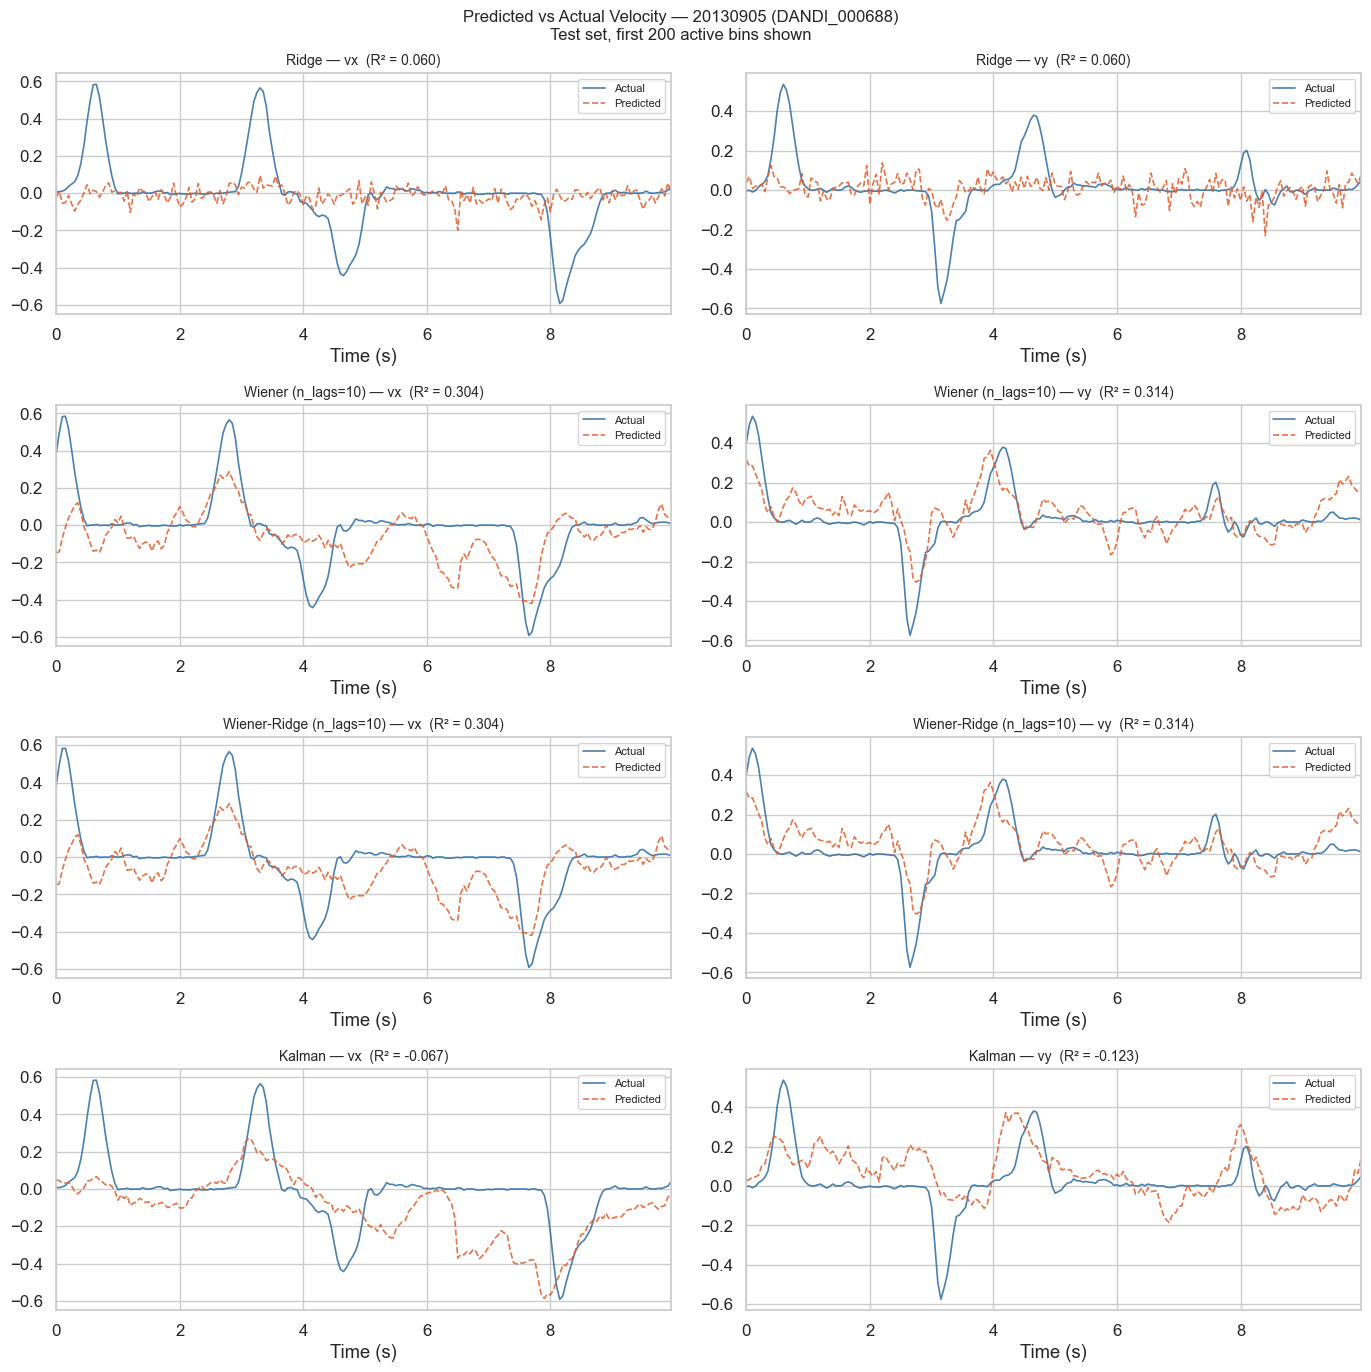

Saved: 01_ContinuousDecoding_DANDI688_velocity.png


In [ ]:
# Re-fit decoders using best_hps and predict on the final test set
# Ridge
dec_r = RidgeDecoder(alpha=float(best_hps['Ridge'].split('=')[1]))
dec_r.fit(X_train_pca_f, y_train_final)
y_pred_ridge = dec_r.predict(X_test_pca_f)
r2_ridge = dec_r.score(X_test_pca_f, y_test_final)

# WienerFilter
n_lags_w = int(float(best_hps['WienerFilter'].split('=')[1]))
dec_w = WienerFilterDecoder(n_lags=n_lags_w)
dec_w.fit(X_train_pca_f, y_train_final)
y_pred_wiener = dec_w.predict(X_test_pca_f)
y_test_wiener = y_test_final[n_lags_w:]
r2_wiener = dec_w.score(X_test_pca_f, y_test_final)

# WienerRidge
hp_wr = {k: float(v) for k, v in (kv.split('=') for kv in best_hps['WienerRidge'].split(','))}
dec_wr = WienerRidgeDecoder(n_lags=int(hp_wr['lag']), alpha=hp_wr['alpha'])
dec_wr.fit(X_train_pca_f, y_train_final)
y_pred_wiener_ridge = dec_wr.predict(X_test_pca_f)
y_test_wiener_ridge = y_test_final[int(hp_wr['lag']):]
r2_wiener_ridge = dec_wr.score(X_test_pca_f, y_test_final)

# Kalman
hp_k = {k: float(v) for k, v in (kv.split('=') for kv in best_hps['Kalman'].split(','))}
dec_k = KalmanFilterDecoder(C=hp_k['C'], lag=int(hp_k['lag']))
dec_k.fit(X_train_pca_f, y_train_final)
y_pred_kalman = dec_k.predict(X_test_pca_f, y_test_final)
y_test_kalman = y_test_final[int(hp_k['lag']):]
r2_kalman = dec_k.score(X_test_pca_f, y_test_final)

# Plot predicted vs actual for each decoder
pb_r = min(PLOT_BINS, len(y_test_final))
pb_w = min(PLOT_BINS, len(y_test_wiener))
pb_wr = min(PLOT_BINS, len(y_test_wiener_ridge))
pb_k = min(PLOT_BINS, len(y_test_kalman))
t_r  = np.arange(pb_r) * BIN_SIZE_MS / 1000
t_w  = np.arange(pb_w) * BIN_SIZE_MS / 1000
t_wr  = np.arange(pb_wr) * BIN_SIZE_MS / 1000
t_k  = np.arange(pb_k) * BIN_SIZE_MS / 1000

def _plot(ax, t, y_true, y_pred, r2_val, title):
    ax.plot(t, y_true, color="#2d6a9f", lw=1.2, label="Actual",    alpha=0.85)
    ax.plot(t, y_pred, color="#e05c2a", lw=1.2, label="Predicted", ls="--", alpha=0.85)
    ax.set_title(f"{title}  (R² = {r2_val:.3f})", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(t[0], t[-1])

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle(
    f"Predicted vs Actual Velocity — {session_id} (DANDI_000688)\n"
    f"Test set, first {PLOT_BINS} active bins shown",
    fontsize=12,
)

_plot(axes[0, 0], t_r, y_test_final[:pb_r, 0], y_pred_ridge[:pb_r, 0],   r2_ridge[0],  "Ridge — vx")
_plot(axes[0, 1], t_r, y_test_final[:pb_r, 1], y_pred_ridge[:pb_r, 1],   r2_ridge[1],  "Ridge — vy")
_plot(axes[1, 0], t_w, y_test_wiener[:pb_w, 0], y_pred_wiener[:pb_w, 0], r2_wiener[0], f"Wiener (n_lags={n_lags_w}) — vx")
_plot(axes[1, 1], t_w, y_test_wiener[:pb_w, 1], y_pred_wiener[:pb_w, 1], r2_wiener[1], f"Wiener (n_lags={n_lags_w}) — vy")
_plot(axes[2, 0], t_wr, y_test_wiener_ridge[:pb_wr, 0], y_pred_wiener_ridge[:pb_wr, 0], r2_wiener_ridge[0], f"Wiener-Ridge (n_lags={int(hp_wr['lag'])}) — vx")
_plot(axes[2, 1], t_wr, y_test_wiener_ridge[:pb_wr, 1], y_pred_wiener_ridge[:pb_wr, 1], r2_wiener_ridge[1], f"Wiener-Ridge (n_lags={int(hp_wr['lag'])}) — vy")
_plot(axes[3, 0], t_k, y_test_kalman[:pb_k, 0], y_pred_kalman[:pb_k, 0], r2_kalman[0], "Kalman — vx")
_plot(axes[3, 1], t_k, y_test_kalman[:pb_k, 1], y_pred_kalman[:pb_k, 1], r2_kalman[1], "Kalman — vy")

plt.tight_layout()
plt.savefig("01_ContinuousDecoding_DANDI688_velocity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 01_ContinuousDecoding_DANDI688_velocity.png")